# Database-Driven Death Cross Detection System
**Data Analytics Pipeline untuk mendeteksi sinyal Death Cross langsung dari PostgreSQL**

---

Notebook ini menghubungkan analisis teknikal Death Cross dengan database PostgreSQL yang telah diimpor dari file CSV transaksi harian.

## Blok 1: Setup & Konfigurasi Koneksi Database
Mengimpor library dan memuat konfigurasi koneksi dari `db_config.json`.

In [ ]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Memuat konfigurasi database
config_path = 'db_config.json'
if not os.path.exists(config_path):
    raise FileNotFoundError(f"File '{config_path}' tidak ditemukan. Silakan jalankan 'auto_import.py' terlebih dahulu.")

with open(config_path, 'r') as f:
    config = json.load(f)

user = config.get('username', 'postgres')
pwd = config.get('password', 'postgres')
host = config.get('host', 'localhost')
port = config.get('port', 5432)
db_name = config.get('database', 'saham_db')
table_name = config.get('table_name', 'transaksi_harian')

print("Konfigurasi berhasil dimuat.")
print(f"Database: {db_name} | Tabel: {table_name}")

Konfigurasi berhasil dimuat.
Database: saham_db | Tabel: transaksi_harian


## Blok 2: Mengambil Data dari PostgreSQL
Menghubungkan ke PostgreSQL dan mengambil riwayat harga saham untuk kode saham tertentu.

In [ ]:
TARGET_STOCK = 'boga' 

# Membuat koneksi engine
db_url = f"postgresql://{user}:{pwd}@{host}:{port}/{db_name}"
engine = create_engine(db_url)

query = """
    SELECT tanggal as "Date", close_price as "Close", volume as "Volume", open_price as "Open", high_price as "High", low_price as "Low"
    FROM transaksi_harian
    WHERE kode = :stock_code
    ORDER BY tanggal ASC
"""

try:
    with engine.connect() as conn:
        df = pd.read_sql_query(text(query), conn, params={"stock_code": TARGET_STOCK.lower()})

    if df.empty:
        print(f"Tidak ada data untuk kode saham '{TARGET_STOCK}' di database.")
    else:
        df['Date'] = pd.to_datetime(df['Date'])
        print(f"Berhasil memuat {len(df)} baris data untuk saham '{TARGET_STOCK.upper()}'")
        print(df.head())
except Exception as e:
    print(f"Gagal memuat data dari database: {e}")

Berhasil memuat 34 baris data untuk saham 'BOLT'
        Date  Close  Volume   Open   High    Low
0 2026-03-25  905.0   11800  920.0  925.0  905.0
1 2026-03-26  910.0    6900    0.0  910.0  905.0
2 2026-03-27  890.0   15700  910.0  910.0  890.0
3 2026-03-30  885.0    6500    0.0  890.0  885.0
4 2026-03-31  880.0    8000  885.0  890.0  880.0


## Blok 3: Menghitung Sinyal Death Cross (SMA 5 vs SMA 20)
Karena data PostgreSQL saat ini mencakup riwayat transaksi harian yang lengkap (sekitar 244 hari perdagangan atau 1 tahun), kita dapat menghitung SMA jangka menengah. Namun, untuk visualisasi pergerakan harian yang lebih responsif dan sensitif terhadap fluktuasi jangka pendek, kita akan menggunakan kombinasi parameter SMA 5 (jangka pendek) dan SMA 20 (jangka menengah).

In [ ]:
if not df.empty:
    SHORT_WINDOW = 5
    LONG_WINDOW = 20

    # Hitung Simple Moving Average
    df['SMA_5'] = df['Close'].rolling(window=SHORT_WINDOW).mean()
    df['SMA_20'] = df['Close'].rolling(window=LONG_WINDOW).mean()

    # Deteksi perpotongan (Death Cross)
    df['Position'] = np.where(df['SMA_5'] > df['SMA_20'], 1, 0)
    df['Crossover'] = df['Position'].diff()
    df['Death_Cross'] = np.where(df['Crossover'] == -1, True, False)
    df['Signal'] = np.where(df['Death_Cross'], 'DEATH CROSS', 'HOLD')
    df.loc[(df['Signal'] == 'HOLD') & (df['Position'] == 1), 'Signal'] = 'SAFE'

    # Tampilkan detail Death Cross jika ada
    death_cross_events = df[df['Death_Cross'] == True]
    print(f"Jumlah Death Cross terdeteksi: {len(death_cross_events)}")
    if len(death_cross_events) > 0:
        print(death_cross_events[['Date', 'Close', 'SMA_5', 'SMA_20', 'Signal']])
else:
    print("Data kosong, silakan periksa kode saham Anda.")

Jumlah Death Cross terdeteksi: 1
         Date  Close  SMA_5  SMA_20       Signal
28 2026-05-11  865.0  924.0   924.0  DEATH CROSS


## Blok 4: Visualisasi Grafik Analisis
Menampilkan grafik harga penutupan, garis SMA 5, SMA 20, dan titik Death Cross.

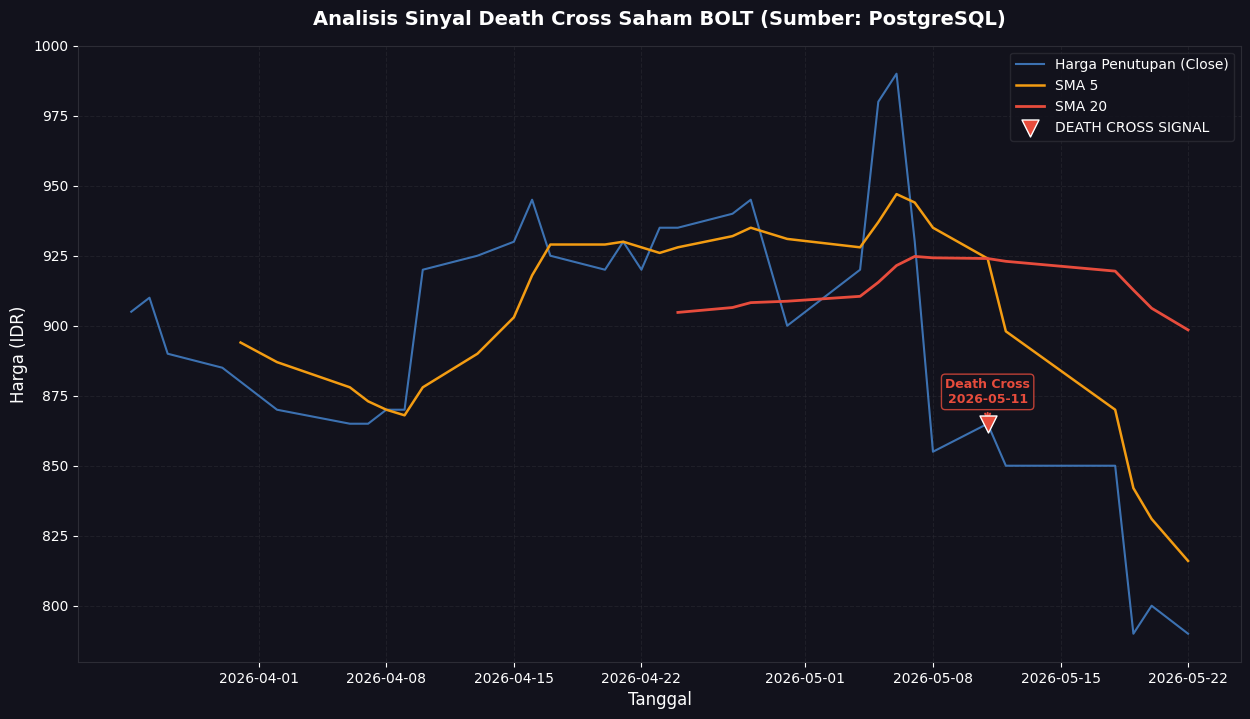

Grafik disimpan sebagai: death_cross_bolt.png


In [ ]:
if not df.empty:
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(15, 8), facecolor='#12121c')
    ax.set_facecolor('#12121c')
    
    # Plot harga penutupan dan SMA
    ax.plot(df['Date'], df['Close'], label='Harga Penutupan (Close)', color='#4e9af1', linewidth=1.5, alpha=0.7)
    ax.plot(df['Date'], df['SMA_5'], label='SMA 5', color='#f39c12', linewidth=1.8)
    ax.plot(df['Date'], df['SMA_20'], label='SMA 20', color='#e74c3c', linewidth=2.0)

    # Menandai titik Death Cross
    if len(death_cross_events) > 0:
        ax.scatter(death_cross_events['Date'], death_cross_events['Close'], 
                    color='#e74c3c', marker='v', s=150, zorder=5, label='DEATH CROSS SIGNAL', edgecolors='white')
        for idx, row in death_cross_events.iterrows():
            ax.annotate(f"Death Cross\n{row['Date'].strftime('%Y-%m-%d')}", 
                         (row['Date'], row['Close']), textcoords="offset points", 
                         xytext=(0,15), ha='center', fontsize=9, color='#e74c3c', fontweight='bold',
                         bbox=dict(boxstyle='round,pad=0.3', facecolor='#12121c', edgecolor='#e74c3c', alpha=0.8),
                         arrowprops=dict(arrowstyle="->", color='#e74c3c', lw=1.5))

    ax.set_title(f"Analisis Sinyal Death Cross Saham {TARGET_STOCK.upper()} (Sumber: PostgreSQL)", fontsize=14, color='white', fontweight='bold', pad=15)
    ax.set_xlabel('Tanggal', fontsize=12, color='white')
    ax.set_ylabel('Harga (IDR)', fontsize=12, color='white')
    ax.grid(True, linestyle='--', color='#2c2c35', alpha=0.5)
    ax.legend(loc='best', facecolor='#12121c', edgecolor='#2c2c35', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2c2c35')
        
    # Simpan hasil grafik
    chart_filename = f"death_cross_{TARGET_STOCK}.png"
    plt.savefig(chart_filename, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"Grafik disimpan sebagai: {chart_filename}")
else:
    print("Tidak ada data untuk divisualisasikan.")

## Blok 5: Visualisasi Grafik Interaktif (Plotly)
Membuat grafik interaktif yang dapat di-zoom, digeser, dan menunjukkan detail harga saat kursor diarahkan ke grafik. Grafik ini akan otomatis disimpan sebagai file HTML dan dibuka di web browser.

In [ ]:
if not df.empty:
    import plotly.graph_objects as go
    import webbrowser
    import shutil
    
    # Inisialisasi grafik Plotly
    fig = go.Figure()

    # 1. Menambahkan grafik Harga Penutupan (Close)
    fig.add_trace(go.Scatter(
        x=df['Date'], 
        y=df['Close'], 
        name='Close Price', 
        line=dict(color='#4e9af1', width=2)
    ))

    # 2. Menambahkan grafik SMA 5
    fig.add_trace(go.Scatter(
        x=df['Date'], 
        y=df['SMA_5'], 
        name='SMA 5', 
        line=dict(color='#f39c12', width=1.5, dash='dash')
    ))

    # 3. Menambahkan grafik SMA 20
    fig.add_trace(go.Scatter(
        x=df['Date'], 
        y=df['SMA_20'], 
        name='SMA 20', 
        line=dict(color='#e74c3c', width=2.0, dash='dash')
    ))

    # 4. Menambahkan Penanda Death Cross
    death_cross_events = df[df['Death_Cross'] == True]
    if not death_cross_events.empty:
        fig.add_trace(go.Scatter(
            x=death_cross_events['Date'],
            y=death_cross_events['Close'],
            mode='markers+text',
            name='Death Cross Signal',
            text=['Death Cross'] * len(death_cross_events),
            textposition='top center',
            marker=dict(symbol='triangle-down', size=14, color='#e74c3c', line=dict(color='white', width=1)),
            textfont=dict(color='#e74c3c', size=11, family='Outfit, Inter, sans-serif')
        ))

    # Mengatur layout dengan tema gelap premium dan tanpa range slider
    fig.update_layout(
        title=dict(
            text=f'Death Cross Technical Analysis (Interactive) - {TARGET_STOCK.upper()}',
            font=dict(color='white', size=22, family='Outfit, Inter, sans-serif'),
            x=0.5
        ),
        hovermode='x unified',
        paper_bgcolor='#12121c',
        plot_bgcolor='#12121c',
        legend=dict(
            font=dict(color='white'),
            bgcolor='rgba(0,0,0,0)',
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        xaxis=dict(
            title=dict(text='Date', font=dict(color='white')),
            tickfont=dict(color='white'),
            gridcolor='#2c2c35',
            linecolor='#2c2c35',
            rangeslider=dict(visible=False),
            showspikes=True,
            spikemode='across',
            spikesnap='cursor',
            spikethickness=1,
            spikedash='dash',
            spikecolor='#888888'
        ),
        yaxis=dict(
            title=dict(text='Price (IDR)', font=dict(color='white')),
            tickfont=dict(color='white'),
            gridcolor='#2c2c35',
            linecolor='#2c2c35',
            showspikes=True,
            spikemode='across',
            spikesnap='cursor',
            spikethickness=1,
            spikedash='dash',
            spikecolor='#888888'
        ),
        margin=dict(l=40, r=40, t=80, b=40)
    )

    # Menyimpan file HTML interaktif spesifik untuk kode saham
    html_filename = f'death_cross_{TARGET_STOCK.lower()}_interactive.html'
    fig.write_html(html_filename)
    print(f"File interaktif berhasil disimpan: {html_filename}")
    
    # Menyimpan salinan file HTML generik agar selalu memiliki hasil terupdate
    generic_filename = 'death_cross_interactive.html'
    shutil.copyfile(html_filename, generic_filename)
    print(f"Salinan generik berhasil disimpan: {generic_filename}")
    
    # Membuka file interaktif di browser secara otomatis
    print("Membuka grafik interaktif di browser...")
    webbrowser.open(os.path.abspath(html_filename))
else:
    print("Data kosong, gagal membuat grafik interaktif.")


File interaktif berhasil disimpan: death_cross_bolt_interactive.html
Salinan generik berhasil disimpan: death_cross_interactive.html
Membuka grafik interaktif di browser...
